# GLMs for Count Data in R

## Overview

Count data — non-negative integers representing the number of times something occurred — violate the assumptions of linear regression. They are bounded at zero, often right-skewed, and their variance typically increases with the mean. Generalized linear models (GLMs) with appropriate error distributions handle these properties correctly.

| Model | Use Case |
|---|---|
| Poisson regression | Count data where mean ≈ variance |
| Negative binomial regression | Overdispersed counts (variance > mean) — the most common real-world case |
| Zero-inflated Poisson (ZIP) | Excess zeros beyond what Poisson predicts |
| Zero-inflated negative binomial (ZINB) | Excess zeros AND overdispersion |
| Hurdle model | Two-part model: first models zero vs. non-zero, then models positive counts |

> **Overdispersion is the rule, not the exception.** In practice, negative binomial regression is appropriate more often than Poisson. Always test for overdispersion after fitting a Poisson model.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | What environmental variables predict invertebrate counts per sample? How does bird species abundance vary with habitat characteristics across survey points? What predicts the number of microplastic particles per water sample? |
| **Healthcare** | What factors predict number of hospital readmissions? How do patient characteristics predict emergency department visits per year? What predicts number of adverse events? |
| **Finance** | What predicts number of transactions per customer per month? How many fraud events occur per account segment? |
| **Insurance** | What predicts number of claims filed per policyholder per year? How do risk factors affect claim frequency? |

---

## Assumptions Checklist

**All count models:**
- [ ] Response is a non-negative integer (count)
- [ ] Observations are independent
- [ ] The log of the expected count is linearly related to the predictors (log-linearity)
- [ ] No influential outliers driving results

**Poisson specifically:**
- [ ] Mean ≈ variance (equidispersion) — test with dispersion test after fitting

**Negative binomial:**
- [ ] Variance > mean (overdispersion) — relaxes the Poisson equidispersion constraint

**Zero-inflated models:**
- [ ] Excess zeros beyond what the count distribution predicts — test with rootogram or zero-inflation test
- [ ] Two distinct processes generating zeros: structural zeros (can never occur) and sampling zeros (could occur but didn't)

> **If non-independence exists** (repeated measures, nested sampling): use GLMMs (see `03_mixed_effects_models/glmm_basics.ipynb`)

---

## Setup

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
library(tidyverse)
library(ggplot2)
library(MASS)         # glm.nb() for negative binomial
library(pscl)         # zeroinfl() and hurdle() for zero-inflated models
library(DHARMa)       # simulation-based residual diagnostics for GLMs
library(performance)  # check_overdispersion(), check_zeroinflation()
library(broom)        # tidy model output
library(AER)          # dispersiontest() for Poisson
library(brms)         # pp_check() for rootogram visualization

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'MASS' was built under R version 4.4.3"

Attaching package: 'MASS'


The following object is masked from 'p

## Data

We simulate two datasets:
1. **Invertebrate counts** — counts per sediment sample across sites with varying pH and organic content. Mirrors the microplastics and invertebrate community work directly.
2. **Claims count** — number of insurance claims per policyholder per year, with overdispersion and excess zeros.

Invertebrate counts:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   11.00   29.50   41.17   54.75  198.00 

Mean: 41.17 | Variance: 1613.50 | Zero proportion: 2.0%

Claims counts:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    0.00    1.06    1.00    8.00 

Mean: 1.06 | Variance: 3.55 | Zero proportion: 65.3%


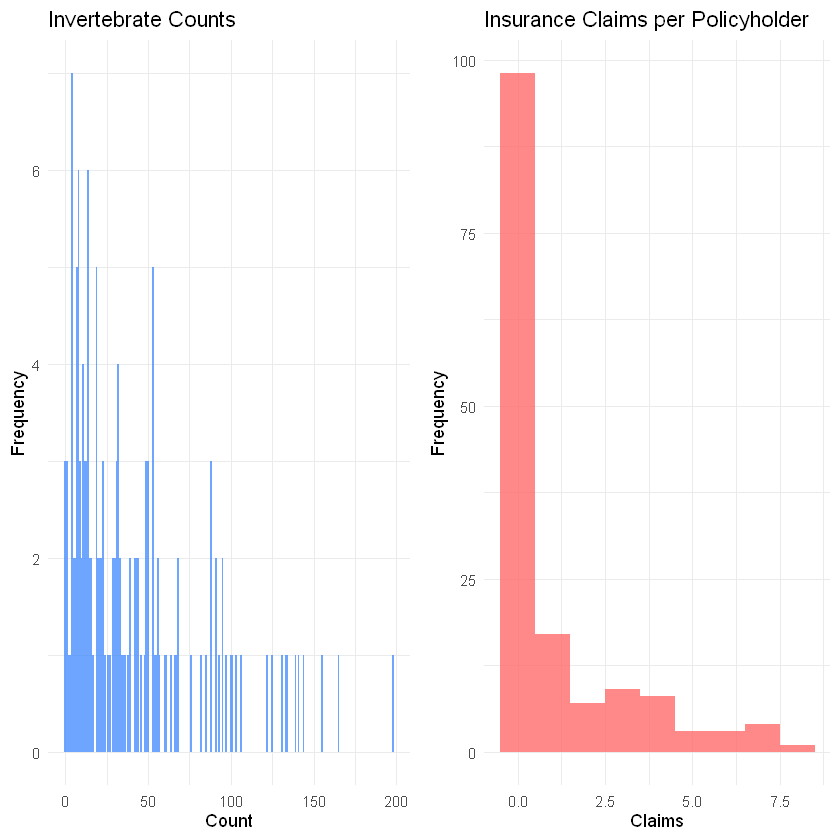

In [2]:
# ── Simulate invertebrate count data (ecology example) ───────────────────────
n <- 150
invert_data <- tibble(
  pH           = rnorm(n, mean = 7.5, sd = 0.8),
  organic_pct  = runif(n, min = 1, max = 15),
  log_count    = 1.2 + 0.4 * pH - 0.08 * organic_pct + rnorm(n, 0, 0.5),
  count        = rnegbin(n, mu = exp(log_count), theta = 2)  # overdispersed
)

# ── Simulate claims count data (insurance example) ───────────────────────────
claims_data <- tibble(
  age          = sample(25:75, n, replace = TRUE),
  risk_score   = runif(n, 1, 10),
  log_lambda   = -1 + 0.01 * age + 0.15 * risk_score,
  claims       = ifelse(runif(n) < 0.45, 0,   # structural zeros
                        rnegbin(n, mu = exp(log_lambda), theta = 1.5))
)

# ── Inspect distributions ─────────────────────────────────────────────────────
cat("Invertebrate counts:\n")
summary(invert_data$count)
cat(sprintf("Mean: %.2f | Variance: %.2f | Zero proportion: %.1f%%\n",
            mean(invert_data$count),
            var(invert_data$count),
            mean(invert_data$count == 0) * 100))

cat("\nClaims counts:\n")
summary(claims_data$claims)
cat(sprintf("Mean: %.2f | Variance: %.2f | Zero proportion: %.1f%%\n",
            mean(claims_data$claims),
            var(claims_data$claims),
            mean(claims_data$claims == 0) * 100))

# ── Visualize distributions ───────────────────────────────────────────────────
p1 <- ggplot(invert_data, aes(x = count)) +
  geom_histogram(binwidth = 1, fill = "#4a8fff", alpha = 0.8) +
  labs(title = "Invertebrate Counts", x = "Count", y = "Frequency") +
  theme_minimal()

p2 <- ggplot(claims_data, aes(x = claims)) +
  geom_histogram(binwidth = 1, fill = "#ff6b6b", alpha = 0.8) +
  labs(title = "Insurance Claims per Policyholder", x = "Claims", y = "Frequency") +
  theme_minimal()

gridExtra::grid.arrange(p1, p2, ncol = 2)

---

## Poisson Regression

The starting point for count data. Fit Poisson first, then test for overdispersion to determine if negative binomial is needed.

In [3]:
# ── Fit Poisson model ─────────────────────────────────────────────────────────
model_pois <- glm(count ~ pH + organic_pct,
                  data   = invert_data,
                  family = poisson(link = "log"))
summary(model_pois)

# ── Interpret coefficients ────────────────────────────────────────────────────
# Exponentiate to get incidence rate ratios (IRR)
# IRR > 1: predictor increases expected count
# IRR < 1: predictor decreases expected count
exp(coef(model_pois))           # IRRs
exp(confint(model_pois))        # 95% CIs for IRRs

broom::tidy(model_pois, exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── Test for overdispersion ───────────────────────────────────────────────────
# If overdispersion present, Poisson SEs are underestimated → inflated type I error
AER::dispersiontest(model_pois)
# H0: dispersion = 1 (equidispersion)
# p < 0.05: overdispersion present → use negative binomial

performance::check_overdispersion(model_pois)

# ── Offset: adjusting for unequal sampling effort ────────────────────────────
# Use offset when counts come from unequal area, time, or sampling effort
# E.g., counts per sample of varying size
invert_data$log_area <- log(runif(n, 0.5, 2))  # simulated sampling area
model_pois_offset <- glm(count ~ pH + organic_pct + offset(log_area),
                          data   = invert_data,
                          family = poisson)
# Now models count RATE (count per unit area) rather than raw count


Call:
glm(formula = count ~ pH + organic_pct, family = poisson(link = "log"), 
    data = invert_data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.921507   0.128961   22.65   <2e-16 ***
pH           0.187510   0.016658   11.26   <2e-16 ***
organic_pct -0.088164   0.003293  -26.78   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 5227.6  on 149  degrees of freedom
Residual deviance: 4332.8  on 147  degrees of freedom
AIC: 5085.2

Number of Fisher Scoring iterations: 5


(Intercept)          pH organic_pct 
 18.5692438   1.2062423   0.9156107

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),14.4168803,23.9009645
pH,1.1675190,1.2463004
organic_pct,0.9097063,0.9215245


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),18.569,0.129,22.654,0,14.417,23.901
pH,1.206,0.017,11.256,0,1.168,1.246
organic_pct,0.916,0.003,-26.776,0,0.910,0.922



	Overdispersion test

data:  model_pois
z = 5.0833, p-value = 1.855e-07
alternative hypothesis: true dispersion is greater than 1
sample estimates:
dispersion 
  33.63021 


Overdispersion detected.



# Overdispersion test

       dispersion ratio =   34.310
  Pearson's Chi-Squared = 5043.561
                p-value =  < 0.001


---

## Negative Binomial Regression

Preferred over Poisson when variance > mean (overdispersion). Adds a dispersion parameter θ (theta) that allows variance to exceed the mean. As θ → ∞, negative binomial → Poisson.

In [4]:
# ── Fit negative binomial model ───────────────────────────────────────────────
model_nb <- MASS::glm.nb(count ~ pH + organic_pct,
                          data = invert_data)
summary(model_nb)
# Theta: dispersion parameter — smaller = more overdispersion

# ── IRRs and CIs ──────────────────────────────────────────────────────────────
broom::tidy(model_nb, exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── Compare Poisson vs. negative binomial ────────────────────────────────────
# Likelihood ratio test: significant = NB fits significantly better
pchisq(2 * (logLik(model_nb) - logLik(model_pois)),
       df = 1, lower.tail = FALSE)
AIC(model_pois, model_nb)
# Lower AIC favors negative binomial when overdispersion is present


Call:
MASS::glm.nb(formula = count ~ pH + organic_pct, data = invert_data, 
    init.theta = 1.229006167, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.53248    0.72157   3.510 0.000449 ***
pH           0.24448    0.09374   2.608 0.009103 ** 
organic_pct -0.09389    0.01827  -5.139 2.76e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(1.229) family taken to be 1)

    Null deviance: 199.80  on 149  degrees of freedom
Residual deviance: 170.19  on 147  degrees of freedom
AIC: 1399.4

Number of Fisher Scoring iterations: 1


              Theta:  1.229 
          Std. Err.:  0.138 

 2 x log-likelihood:  -1391.407 

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),12.585,0.722,3.510,0.000,2.739,58.462
pH,1.277,0.094,2.608,0.009,1.044,1.562
organic_pct,0.910,0.018,-5.139,0.000,0.878,0.945


'log Lik.' 0 (df=4)

,df,AIC
,<dbl>,<dbl>
model_pois,3,5085.217
model_nb,4,1399.407


---

## Diagnostics with DHARMa

Standard residual plots are misleading for count models. DHARMa uses simulation to produce residuals that should be uniformly distributed if the model fits well.

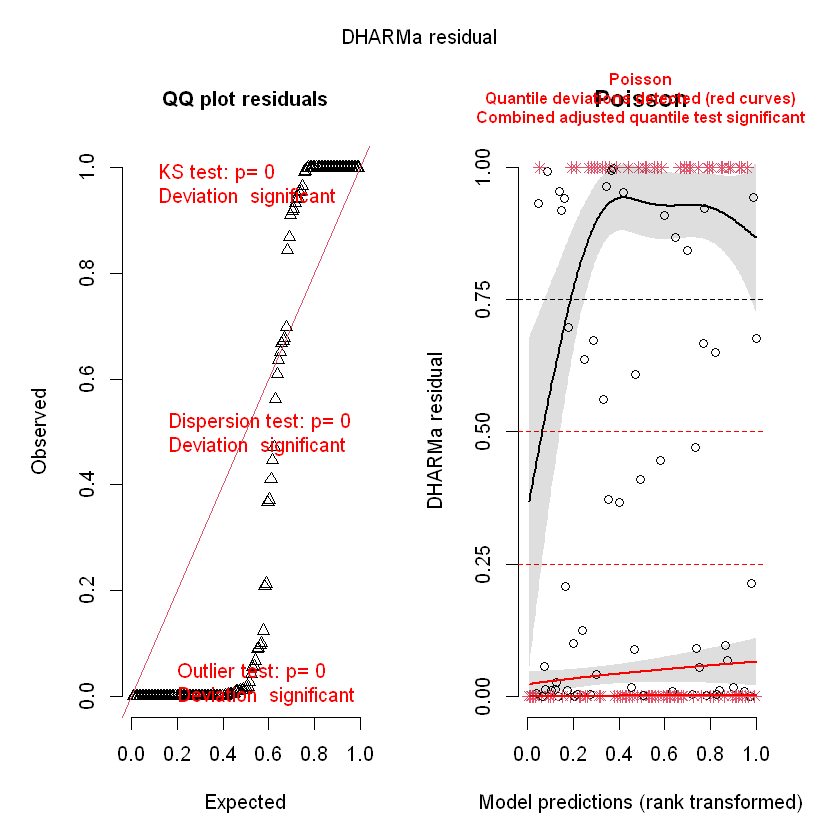

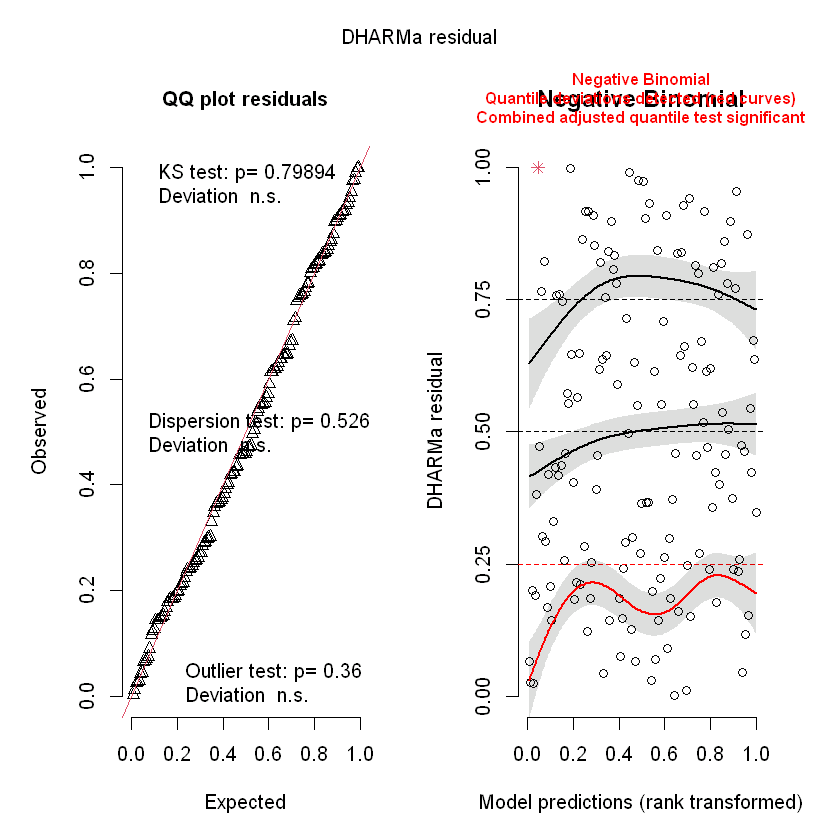


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.81824, p-value = 0.526
alternative hypothesis: two.sided


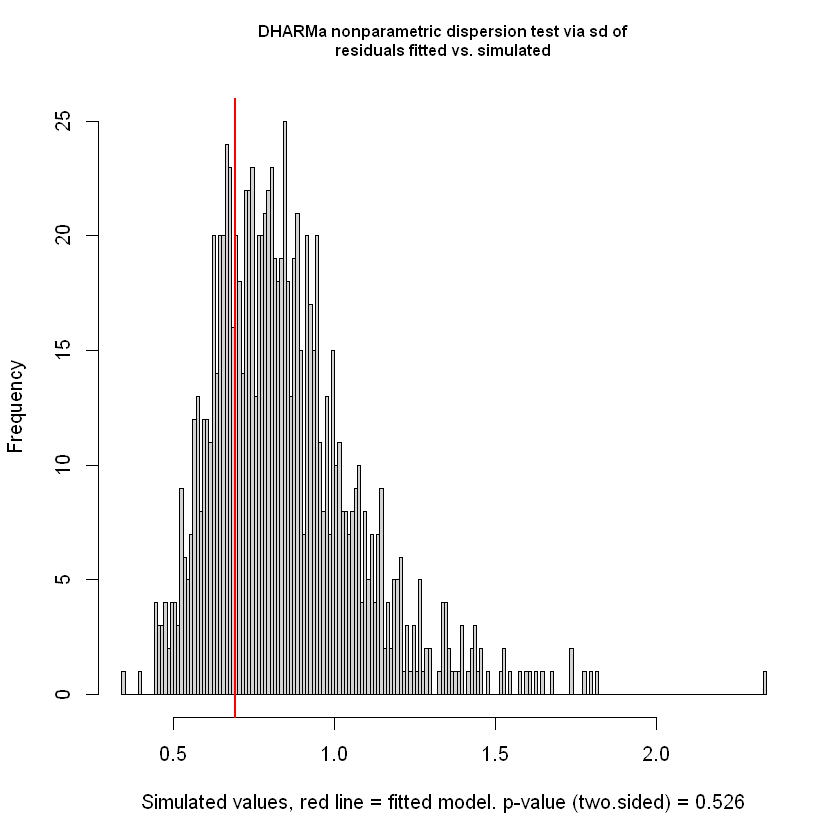


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 1.2092, p-value = 0.914
alternative hypothesis: two.sided


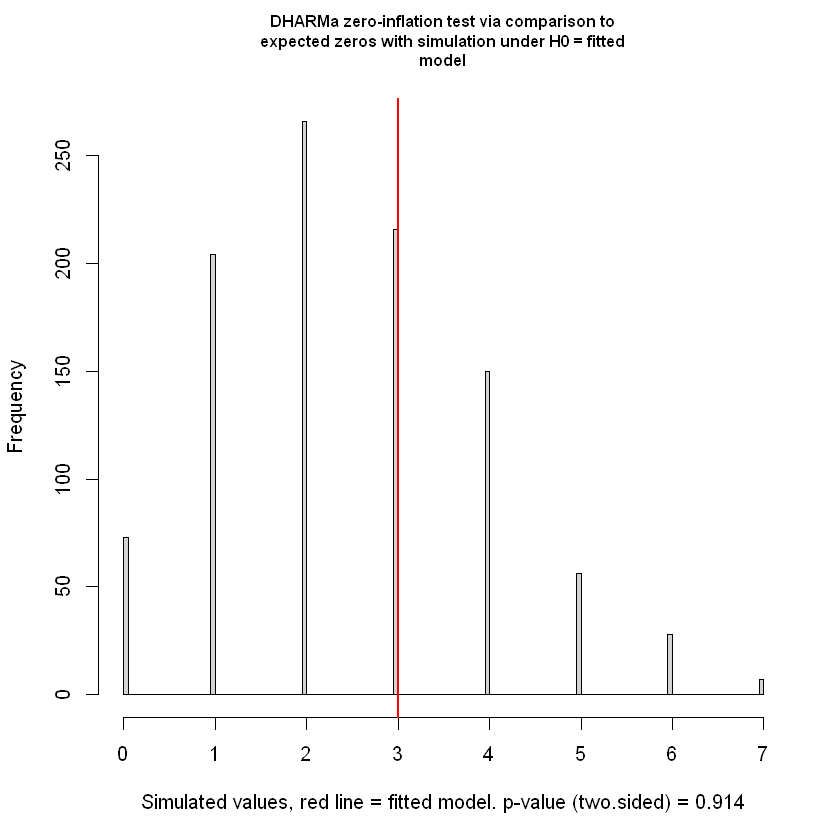


	DHARMa bootstrapped outlier test

data:  sim_resid_nb
outliers at both margin(s) = 1, observations = 150, p-value = 0.34
alternative hypothesis: two.sided
 percent confidence interval:
 0.000000000 0.006666667
sample estimates:
outlier frequency (expected: 0.0012 ) 
                          0.006666667 


,sim_1,sim_2,sim_3,sim_4,sim_5,sim_6,sim_7,sim_8,sim_9,sim_10,⋯,sim_42,sim_43,sim_44,sim_45,sim_46,sim_47,sim_48,sim_49,sim_50,y
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,19,20,20,13,3,19,59,57,26,60,⋯,32,100,80,129,23,19,48,9,113,16
2,0,6,54,17,45,19,41,37,32,12,⋯,63,47,23,16,83,26,10,0,81,14
3,101,26,5,154,19,62,9,123,141,3,⋯,82,60,22,55,46,188,39,103,82,49
4,39,11,19,53,18,19,106,13,168,76,⋯,11,86,13,24,36,86,240,42,57,88
5,33,0,4,16,53,4,6,49,19,12,⋯,0,12,1,69,20,28,12,13,4,155
6,6,2,9,5,14,6,30,42,3,20,⋯,44,27,9,8,9,14,62,4,21,4
7,121,39,12,53,63,8,36,67,34,18,⋯,35,46,15,112,43,150,98,72,163,95
8,2,24,21,22,142,35,113,160,2,14,⋯,48,16,39,109,46,25,31,44,40,19
9,59,4,67,107,68,64,43,13,53,68,⋯,56,63,19,15,50,83,3,81,12,48


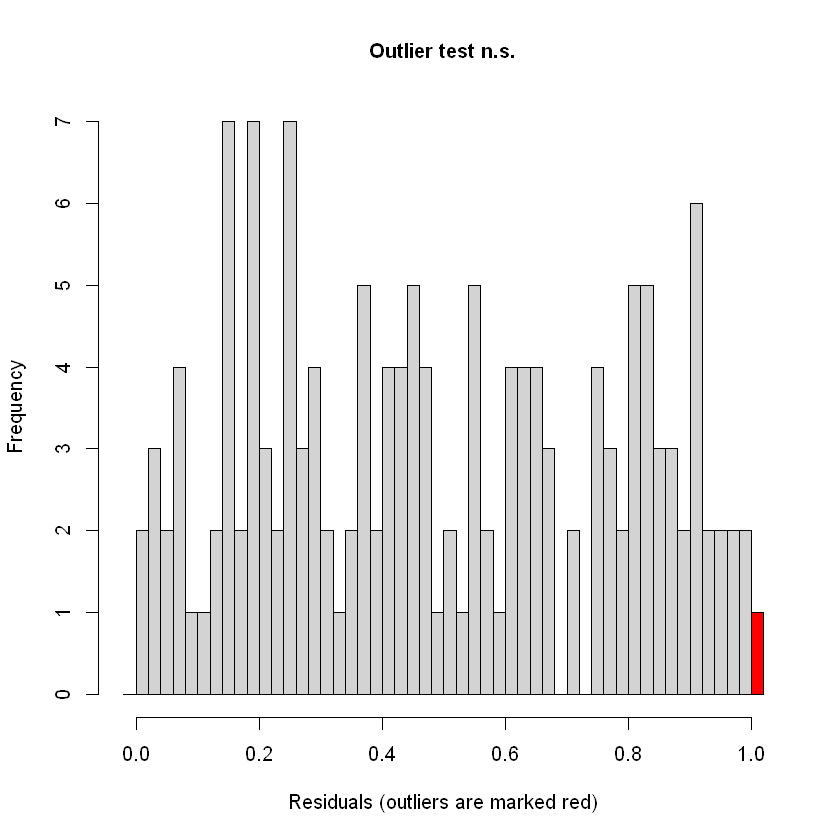

In [5]:
# ── DHARMa simulation-based residuals ────────────────────────────────────────
sim_resid_pois <- DHARMa::simulateResiduals(model_pois, n = 1000)
sim_resid_nb   <- DHARMa::simulateResiduals(model_nb,   n = 1000)

par(mfrow = c(1, 2))
plot(sim_resid_pois, main = "Poisson")
plot(sim_resid_nb,   main = "Negative Binomial")
par(mfrow = c(1, 1))
# Left panel: QQ plot — points on diagonal = uniform residuals = good fit
# Right panel: residuals vs. fitted — no pattern = good

# ── Formal tests ──────────────────────────────────────────────────────────────
DHARMa::testDispersion(sim_resid_nb)      # overdispersion
DHARMa::testZeroInflation(sim_resid_nb)   # excess zeros
DHARMa::testOutliers(sim_resid_nb)        # outliers

# ── Rootogram: observed vs. predicted count frequencies ──────────────────────
# Hanging rootogram — bars hanging from predicted values
# Bars touching the x-axis = perfect fit
brms::pp_check(model_nb, type = "rootogram")

---

## Zero-Inflated and Hurdle Models

When zero counts are more frequent than any count distribution predicts, use a zero-inflated or hurdle model.

- **Zero-inflated:** Assumes zeros come from two sources — a structural process (always zero) and a count process (could be any count including zero). Fits both simultaneously.
- **Hurdle:** First models whether count is zero or positive (logistic), then models positive counts only (truncated count distribution). Cleaner separation between the two processes.


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 1.023, p-value = 0.798
alternative hypothesis: two.sided


Model seems ok, ratio of observed and predicted zeros is within the
  tolerance range (p = 0.816).



# Check for zero-inflation

   Observed zeros: 98
  Predicted zeros: 96
            Ratio: 0.98



Call:
pscl::zeroinfl(formula = claims ~ age + risk_score | age + risk_score, 
    data = claims_data, dist = "negbin")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.8387 -0.5820 -0.4108  0.2317  4.4550 

Count model coefficients (negbin with log link):
             Estimate Std. Error z value Pr(>|z|)  
(Intercept)  0.341739   0.581273   0.588   0.5566  
age         -0.002744   0.007476  -0.367   0.7136  
risk_score   0.108897   0.051761   2.104   0.0354 *
Log(theta)   1.258160   0.753358   1.670   0.0949 .

Zero-inflation model coefficients (binomial with logit link):
            Estimate Std. Error z value Pr(>|z|)   
(Intercept)  2.26357    0.86459   2.618  0.00884 **
age         -0.02000    0.01343  -1.490  0.13626   
risk_score  -0.14858    0.07950  -1.869  0.06164 . 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Theta = 3.5189 
Number of iterations in BFGS optimization: 30 
Log-likelihood: -188.8 on 7 Df


Call:
pscl::hurdle(formula = claims ~ age + risk_score | age + risk_score, 
    data = claims_data, dist = "negbin")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.8447 -0.5820 -0.4111  0.2357  4.4585 

Count model coefficients (truncated negbin with log link):
             Estimate Std. Error z value Pr(>|z|)  
(Intercept)  0.359205   0.586093   0.613   0.5400  
age         -0.003227   0.007665  -0.421   0.6738  
risk_score   0.109817   0.052297   2.100   0.0357 *
Log(theta)   1.248648   0.756074   1.651   0.0986 .
Zero hurdle model coefficients (binomial with logit link):
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.62053    0.74626  -3.512 0.000446 ***
age          0.01729    0.01174   1.473 0.140880    
risk_score   0.18022    0.06706   2.687 0.007202 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Theta: count = 3.4856
Number of iterations in BFGS optimization: 18 
Log-likelihood: -188.7 on 7 Df

,df,AIC
,<dbl>,<dbl>
model_nb_claims,4,395.8292
model_zinb,7,391.5483
model_hurdle,7,391.4389


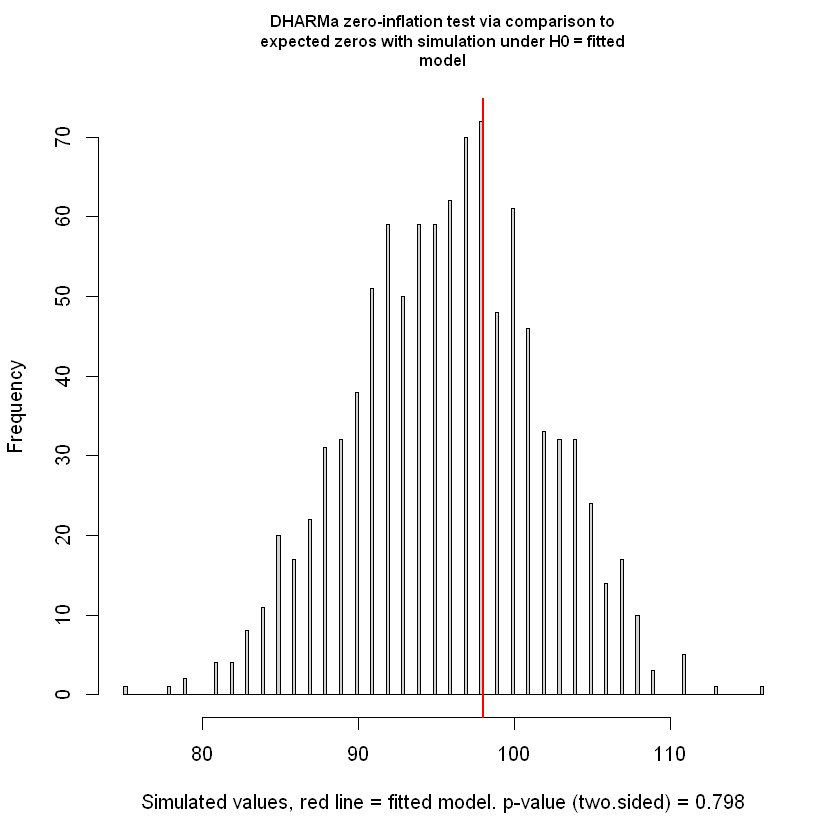

In [6]:
# ── Check for zero inflation in claims data ───────────────────────────────────
model_nb_claims <- MASS::glm.nb(claims ~ age + risk_score, data = claims_data)
sim_claims      <- DHARMa::simulateResiduals(model_nb_claims, n = 1000)
DHARMa::testZeroInflation(sim_claims)
performance::check_zeroinflation(model_nb_claims)
# Significant = excess zeros beyond NB prediction → use zero-inflated model

# ── Zero-inflated negative binomial (ZINB) ────────────────────────────────────
model_zinb <- pscl::zeroinfl(
  claims ~ age + risk_score |  # count model (RHS of |)
            age + risk_score,  # zero-inflation model (what predicts being a structural zero)
  data = claims_data,
  dist = "negbin"
)
summary(model_zinb)
# Two sets of coefficients:
# Count model: effect on expected count (for those not always-zero)
# Zero-inflation model: effect on probability of being a structural zero

# ── Hurdle model ──────────────────────────────────────────────────────────────
model_hurdle <- pscl::hurdle(
  claims ~ age + risk_score |  # count model for positive counts
            age + risk_score,  # binary model for zero vs. positive
  data = claims_data,
  dist = "negbin"
)
summary(model_hurdle)

# ── Compare models ────────────────────────────────────────────────────────────
AIC(model_nb_claims, model_zinb, model_hurdle)
# Lower AIC = better fit

---

## Visualizing Model Predictions

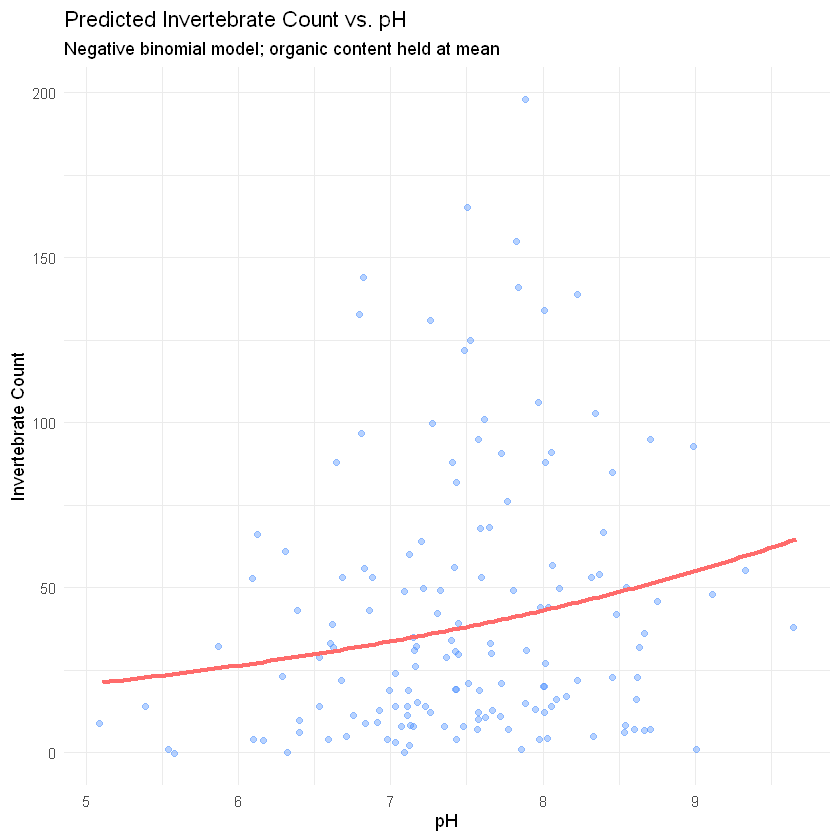

In [7]:
# ── Predicted count over range of pH ─────────────────────────────────────────
pred_grid <- data.frame(
  pH          = seq(min(invert_data$pH), max(invert_data$pH), length.out = 100),
  organic_pct = mean(invert_data$organic_pct)
)

pred_grid$predicted <- predict(model_nb, newdata = pred_grid, type = "response")

ggplot() +
  geom_jitter(data = invert_data,
              aes(x = pH, y = count),
              width = 0.02, height = 0.2,
              alpha = 0.4, color = "#4a8fff") +
  geom_line(data = pred_grid,
            aes(x = pH, y = predicted),
            color = "#ff6b6b", linewidth = 1.2) +
  labs(title = "Predicted Invertebrate Count vs. pH",
       subtitle = "Negative binomial model; organic content held at mean",
       x = "pH", y = "Invertebrate Count") +
  theme_minimal()

---

## Reporting Results

In [8]:
# ── Clean IRR table ───────────────────────────────────────────────────────────
broom::tidy(model_nb, exponentiate = TRUE, conf.int = TRUE) %>%
  rename(IRR = estimate, CI_low = conf.low, CI_high = conf.high) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# Standard reporting format:
# "Sediment pH was a significant positive predictor of invertebrate count
#  (IRR = X.XX, 95% CI [X.XX, X.XX], p = .XXX): each unit increase in pH
#  was associated with a X.X-fold increase in expected invertebrate abundance.
#  A negative binomial model was used to account for overdispersion
#  (θ = X.XX). Model fit was evaluated using DHARMa simulation-based
#  residuals, which indicated no systematic misfit."

term,IRR,std.error,statistic,p.value,CI_low,CI_high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),12.585,0.722,3.510,0.000,2.739,58.462
pH,1.277,0.094,2.608,0.009,1.044,1.562
organic_pct,0.910,0.018,-5.139,0.000,0.878,0.945


---

## Common Pitfalls

**1. Using linear regression for count data**  
Linear regression can produce negative predicted values, assumes constant variance, and is inefficient for count data. Always use a count model.

**2. Defaulting to Poisson without testing for overdispersion**  
Poisson is almost always overdispersed in real ecological and industry data. Overdispersed Poisson underestimates standard errors, inflating type I error. Always test with `dispersiontest()` or DHARMa after fitting Poisson.

**3. Not accounting for unequal sampling effort**  
If counts come from samples of different sizes, areas, or durations, raw counts are not comparable. Use an offset term to model rates.

**4. Confusing zero-inflated and hurdle models**  
Zero-inflated models assume zeros come from two processes (structural and sampling). Hurdle models assume any zero is a non-event, and all positive counts are modeled separately. Choose based on the data-generating mechanism.

**5. Using standard residual plots for GLMs**  
Pearson and deviance residuals for Poisson and NB models do not follow normal distributions. Use DHARMa simulation-based residuals instead.

**6. Reporting log-scale coefficients instead of IRRs**  
Always exponentiate Poisson and NB coefficients to report incidence rate ratios. Raw coefficients are on the log scale and difficult to interpret substantively.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*